# Dự đoán Hỏng hóc Thiết bị dưới Distribution Shift
### Bài tập cuối khoá — Machine Learning

| Họ tên | MSSV |
|---|---|
| Nguyễn Huy Cường     | 25MS23319 |
| Lê Nhựt Thanh Quang  | 25MS23318 |
| Hớn Vĩ Dân           | 25MS23316 |
| Nguyễn Đức Minh Khoa | 25MS23333 |

***
## Bối cảnh & Mục tiêu
Một nhà máy cơ khí vận hành đội máy phay **CNC**. Bộ phận bảo trì muốn dự đoán **thiết bị sẽ hỏng trong ca
sản xuất kế tiếp** (bài toán **phân loại nhị phân**) để chuyển từ *bảo trì bị động* (chạy đến hỏng) sang
*bảo trì chủ động* (predictive maintenance).

| Tập | Dây chuyền | Đặc điểm |
|---|---|---|
| **Train** | Dây chuyền A | Nhà máy cũ, vận hành ổn định ~2 năm, cảm biến hiệu chỉnh chuẩn |
| **Test**  | Dây chuyền B | Nhà máy mới, khí hậu nóng hơn, cảm biến vừa hiệu chỉnh lại, chế độ tải khác |

> **Vấn đề cốt lõi — Distribution Shift:** Train và Test đến từ hai điều kiện vận hành khác nhau. Cùng cơ chế
> vật lý gây hỏng, nhưng **phân phối biến đầu vào bị dịch chuyển**. Phải *phát hiện → định lượng → xử lý* shift
> để mô hình còn hoạt động tốt khi triển khai trên Dây chuyền B.

**Pipeline:** EDA → Tiền xử lý & Feature Engineering → **Phát hiện & Xử lý Distribution Shift (trọng tâm)** →
Mô hình & Đánh giá → Báo cáo.

**Các cơ chế hỏng cơ học tiềm ẩn** (gợi ý của đề, định hướng Feature Engineering):
hao mòn dao · tản nhiệt kém · quá tải công suất · quá tải căng thẳng (overstrain).

## 0. Thiết lập môi trường & nạp dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings; warnings.filterwarnings('ignore')

# Sklearn
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (StratifiedKFold, RandomizedSearchCV,
                                     cross_val_predict, cross_val_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_recall_curve, roc_curve, confusion_matrix)
from scipy.stats import ks_2samp, loguniform, randint
import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({'figure.dpi':110, 'axes.titlesize':11, 'font.size':10})
C_A, C_B, C_GREY = '#4C72B0', '#C44E52', '#8C8C8C'   # A(train), B(test), phụ

# Môi trường tái lập: người chấm đối chiếu phiên bản thư viện với requirements.txt
print(f'scikit-learn {sklearn.__version__} | numpy {np.__version__} | pandas {pd.__version__}')

scikit-learn 1.9.0 | numpy 2.3.5 | pandas 2.3.3


In [2]:
# Nạp dữ liệu — hai dây chuyền
train = pd.read_csv('data/train.csv')
test  = pd.read_csv('data/test.csv')

NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']
CAT = ['loai_san_pham','ca_lam_viec']
TARGET = 'hong_hoc'

print(f'Train (Dây chuyền A): {train.shape}  |  Test (Dây chuyền B): {test.shape}')
print(f'Số giá trị thiếu — train: {train.isnull().sum().sum()}, test: {test.isnull().sum().sum()}')
train.head()

Train (Dây chuyền A): (14000, 8)  |  Test (Dây chuyền B): (6000, 8)
Số giá trị thiếu — train: 0, test: 0


,nhiet_do_moi_truong,nhiet_do_quy_trinh,toc_do_quay,momen_xoan,do_mon_dao,loai_san_pham,ca_lam_viec,hong_hoc
0,301.21,311.80,1864.3,47.52,210.9,H,Chiều,0
1,302.66,311.52,1727.1,49.32,175.7,L,Đêm,0
2,300.39,312.23,1516.6,42.70,54.5,L,Sáng,0
3,298.27,308.38,1555.3,23.12,247.7,M,Sáng,1
4,301.02,310.22,1356.7,39.02,30.4,M,Đêm,0


***
# Phần 1 — Khám phá dữ liệu (EDA)
Ba nhiệm vụ: (1) thống kê mô tả + kiểm tra imbalance của target; (2) so sánh trực quan phân phối
A vs B để phát hiện shift; (3) correlation heatmap và nhận xét feature liên quan nguy cơ hỏng.

### 1.1 Thống kê mô tả & mức mất cân bằng của biến mục tiêu

In [3]:
display(train[NUM].describe().T[['mean','std','min','25%','50%','75%','max']].round(2))
print('Phân bố biến phân loại (train):')
for c in CAT:
    print(f'  {c}: {train[c].value_counts().to_dict()}')
print(f"\nTỉ lệ hỏng — Train: {train[TARGET].mean()*100:.2f}%  |  Test: {test[TARGET].mean()*100:.2f}%")

,mean,std,min,25%,50%,75%,max
nhiet_do_moi_truong,299.99,1.99,292.00,298.64,300.00,301.35,307.54
nhiet_do_quy_trinh,309.98,2.23,300.99,308.46,309.96,311.49,318.86
toc_do_quay,1540.26,174.64,1180.00,1417.18,1537.35,1659.50,2153.50
momen_xoan,39.94,9.96,3.50,33.30,39.89,46.66,76.02
do_mon_dao,126.95,72.69,0.00,64.50,126.20,190.10,253.00


Phân bố biến phân loại (train):
  loai_san_pham: {'L': 7022, 'M': 4204, 'H': 2774}
  ca_lam_viec: {'Sáng': 5675, 'Chiều': 4792, 'Đêm': 3533}

Tỉ lệ hỏng — Train: 7.36%  |  Test: 7.95%


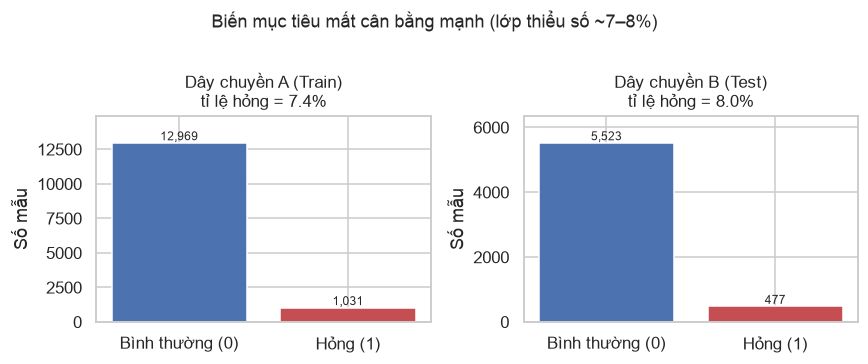

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.2))
for ax, (df, name) in zip(axes, [(train,'Dây chuyền A (Train)'),(test,'Dây chuyền B (Test)')]):
    vc = df[TARGET].value_counts().sort_index(); rate = df[TARGET].mean()*100
    bars = ax.bar(['Bình thường (0)','Hỏng (1)'], vc.values, color=[C_A, C_B])
    for b,v in zip(bars, vc.values):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:,}', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'{name}\ntỉ lệ hỏng = {rate:.1f}%'); ax.set_ylabel('Số mẫu'); ax.margins(y=0.15)
fig.suptitle('Biến mục tiêu mất cân bằng mạnh (lớp thiểu số ~7–8%)', y=1.02)
fig.tight_layout(); plt.show()

**Nhận xét 1.1.** Lớp *hỏng* chỉ chiếm **~7.4%** (train) và **~8.0%** (test) → mất cân bằng mạnh.
Hệ quả: **accuracy vô nghĩa** (đoán "không hỏng" đã đạt >92%); phải dùng **AUC-PR, F1, Precision-Recall**
và xử lý imbalance bằng `class_weight`/SMOTE.

### 1.2 So sánh phân phối Dây chuyền A vs B — dấu hiệu Distribution Shift

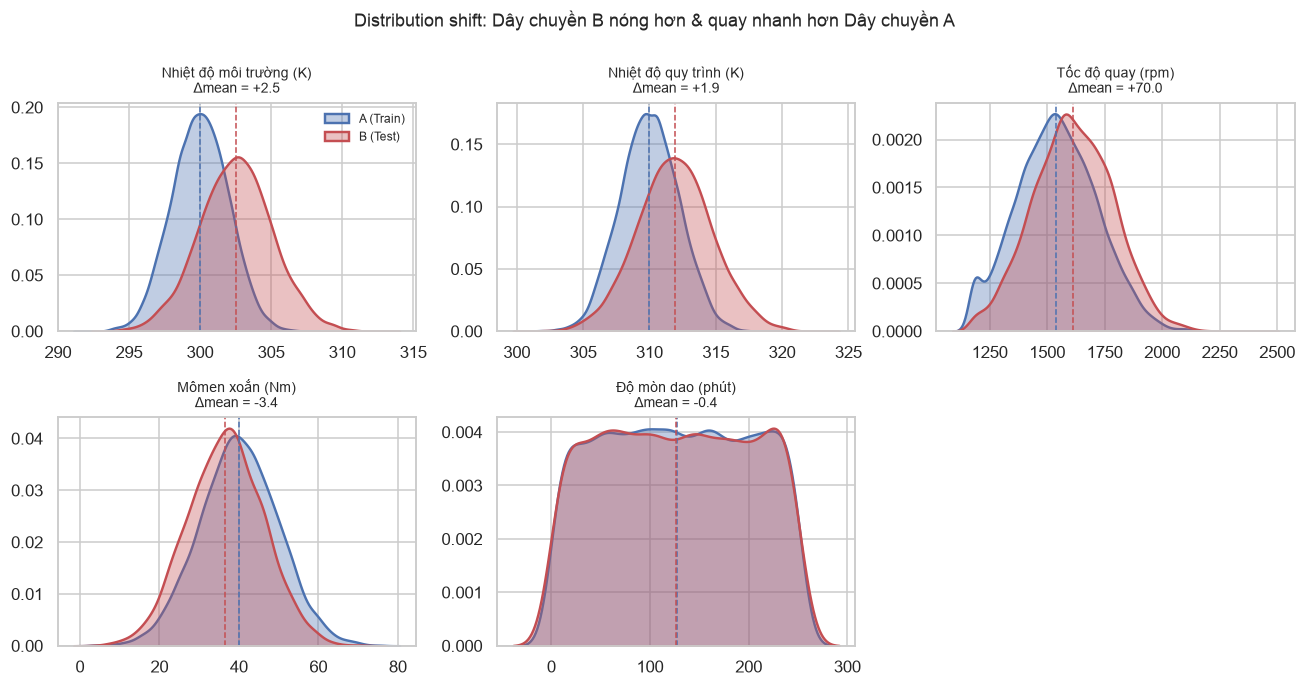

In [5]:
labels = {'nhiet_do_moi_truong':'Nhiệt độ môi trường (K)','nhiet_do_quy_trinh':'Nhiệt độ quy trình (K)',
          'toc_do_quay':'Tốc độ quay (rpm)','momen_xoan':'Mômen xoắn (Nm)','do_mon_dao':'Độ mòn dao (phút)'}
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2)); axes = axes.ravel()
for ax, col in zip(axes, NUM):
    sns.kdeplot(train[col], ax=ax, color=C_A, fill=True, alpha=0.35, lw=1.6, label='A (Train)')
    sns.kdeplot(test[col],  ax=ax, color=C_B, fill=True, alpha=0.35, lw=1.6, label='B (Test)')
    ax.axvline(train[col].mean(), color=C_A, ls='--', lw=1); ax.axvline(test[col].mean(), color=C_B, ls='--', lw=1)
    ax.set_title(f'{labels[col]}\n' + r'$\Delta$mean = ' + f'{test[col].mean()-train[col].mean():+.1f}', fontsize=9)
    ax.set_xlabel(''); ax.set_ylabel('')
axes[0].legend(frameon=False, fontsize=8); axes[-1].axis('off')
fig.suptitle('Distribution shift: Dây chuyền B nóng hơn & quay nhanh hơn Dây chuyền A', y=1.0)
fig.tight_layout(); plt.show()

**Nhận xét 1.2.** Dấu hiệu shift rất rõ, đúng bối cảnh "nhà máy B nóng hơn, tải khác":
- **Nhiệt độ môi trường +2.5K**, **nhiệt độ quy trình +1.9K** → dịch phải mạnh.
- **Tốc độ quay +70 rpm** → B chạy nhanh hơn.
- **Mômen xoắn −3.4 Nm** → B tải nhẹ hơn đôi chút.
- **Độ mòn dao** gần như trùng khớp → biến này **ổn định** giữa hai dây chuyền.

→ Đây là **covariate shift** (P(X) đổi). Phần 3 sẽ định lượng chính xác bằng PSI/KS và drift classifier.

### 1.3 Correlation heatmap & feature liên quan nguy cơ hỏng

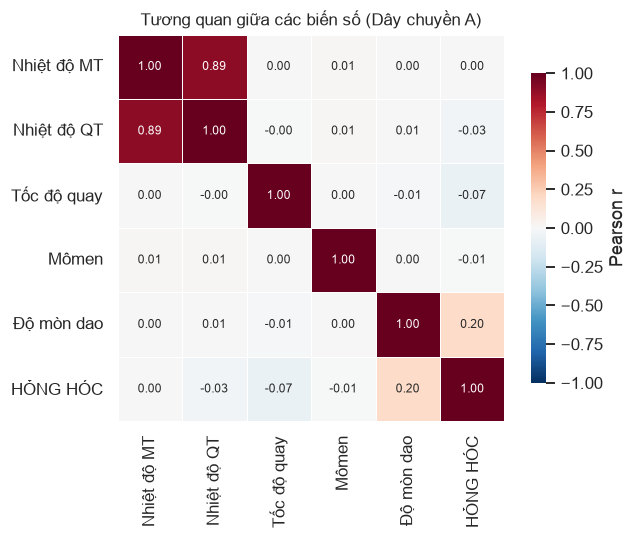

Tương quan tuyến tính với hong_hoc:
do_mon_dao             0.195
toc_do_quay           -0.066
nhiet_do_quy_trinh    -0.033
momen_xoan            -0.006
nhiet_do_moi_truong    0.001


In [6]:
short = {'nhiet_do_moi_truong':'Nhiệt độ MT','nhiet_do_quy_trinh':'Nhiệt độ QT','toc_do_quay':'Tốc độ quay',
         'momen_xoan':'Mômen','do_mon_dao':'Độ mòn dao','hong_hoc':'HỎNG HÓC'}
corr = train[NUM+[TARGET]].rename(columns=short).corr()
fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={'label':'Pearson r','shrink':0.8}, ax=ax, annot_kws={'fontsize':8})
ax.set_title('Tương quan giữa các biến số (Dây chuyền A)'); fig.tight_layout(); plt.show()

print('Tương quan tuyến tính với hong_hoc:')
print(train[NUM].corrwith(train[TARGET]).round(3).sort_values(key=abs, ascending=False).to_string())

**Nhận xét 1.3.**
- `do_mon_dao` có tương quan tuyến tính cao nhất với hỏng (**r ≈ 0.20**) — dao mòn lâu → dễ hỏng.
- Hai biến nhiệt độ tương quan chặt với nhau (**r ≈ 0.89**) vì nhiệt quy trình sinh ra từ nhiệt môi trường.
- Các tương quan tuyến tính còn lại **rất yếu**. Điều này *không* nghĩa là biến vô dụng: cơ chế hỏng cơ học
  là **phi tuyến & tương tác** (VD hỏng khi *mômen cao ĐỒNG THỜI tốc độ thấp*). Đây chính là lý do
  **Feature Engineering** (Phần 2) và **mô hình phi tuyến** (Phần 4) là cần thiết.

### 1.4 Quan hệ giữa biến phân loại và tỉ lệ hỏng

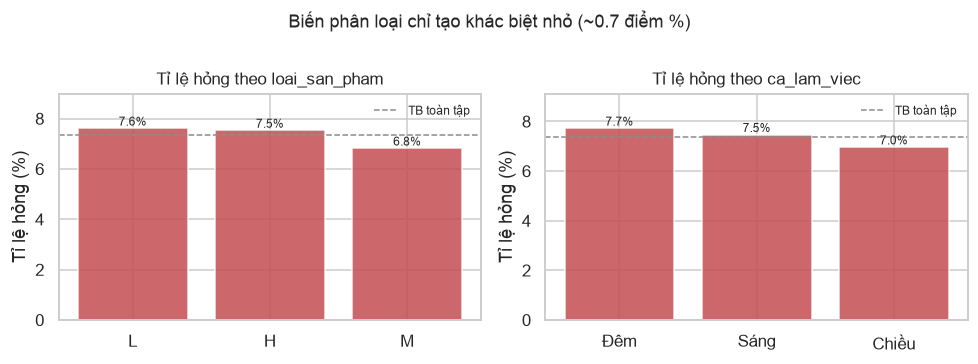

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
for ax, col in zip(axes, CAT):
    rate = train.groupby(col)[TARGET].mean().mul(100).sort_values(ascending=False)
    bars = ax.bar(rate.index.astype(str), rate.values, color=C_B, alpha=0.85)
    ax.axhline(train[TARGET].mean()*100, color=C_GREY, ls='--', lw=1, label='TB toàn tập')
    for b,v in zip(bars, rate.values):
        ax.text(b.get_x()+b.get_width()/2, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=8)
    ax.set_title(f'Tỉ lệ hỏng theo {col}'); ax.set_ylabel('Tỉ lệ hỏng (%)')
    ax.margins(y=0.18); ax.legend(frameon=False, fontsize=8)
fig.suptitle('Biến phân loại chỉ tạo khác biệt nhỏ (~0.7 điểm %)', y=1.02)
fig.tight_layout(); plt.show()

**Nhận xét 1.4.** Sản phẩm hạng **L** và ca **Đêm** có tỉ lệ hỏng nhỉnh hơn, nhưng chênh lệch chỉ
~0.7 điểm phần trăm → tín hiệu yếu. Vẫn giữ lại (one-hot) làm biến bổ trợ.

***
# Phần 2 — Tiền xử lý & Feature Engineering
Ba nhiệm vụ: (1) scaling + encoding + xử lý imbalance; (2) **fit scaler CHỈ trên Train** rồi transform cả
hai (chống rò rỉ dữ liệu Test); (3) tạo ≥2 feature cơ học mới và kiểm chứng tác dụng.

### 2.1 Feature Engineering — biến hoá cơ chế hỏng thành đặc trưng
Mỗi feature mới ánh xạ trực tiếp một **cơ chế hỏng vật lý** trong gợi ý của đề:

| Feature mới | Công thức | Cơ chế hỏng |
|---|---|---|
| `chenh_lech_nhiet` | `nhiet_do_quy_trinh − nhiet_do_moi_truong` | **Tản nhiệt kém** — chênh lệch **nhỏ** = nhiệt bị giữ lại trong máy, không thoát ra được → nguy cơ hỏng cao |
| `cong_suat_co` | `momen_xoan × (toc_do_quay·2π/60)` (Watt) | **Quá tải công suất** — công suất cơ = mômen × tốc độ góc |
| `tich_mon_momen` | `do_mon_dao × momen_xoan` | **Quá tải căng thẳng** — dao mòn chịu mômen lớn = ứng suất cao |
| `strain_index` | `do_mon_dao × momen_xoan / toc_do_quay` | **Overstrain** — mômen/mòn cao ở tốc độ thấp = nguy hiểm nhất |

> **Lưu ý chiều tác động của `chenh_lech_nhiet`:** dòng nhiệt thoát khỏi máy tỉ lệ thuận với ΔT (định luật truyền nhiệt),
> nên ΔT **nhỏ bất thường** nghĩa là môi trường nóng gần bằng điểm gia công — nhiệt không có đường thoát.
> Bảng ngũ phân vị ở mục 2.2 kiểm chứng đúng chiều này: nhóm ΔT **thấp nhất** có tỉ lệ hỏng 11.7% so với ~6% các nhóm còn lại.

In [8]:
def add_features(df):
    d = df.copy()
    d['chenh_lech_nhiet'] = d['nhiet_do_quy_trinh'] - d['nhiet_do_moi_truong']   # ΔT nhỏ = nhiệt kẹt trong máy (tản nhiệt kém)
    d['cong_suat_co']     = d['momen_xoan'] * d['toc_do_quay'] * 2*np.pi/60      # P = τ·ω (Watt); 2π/60 đổi rpm -> rad/s
    d['tich_mon_momen']   = d['do_mon_dao'] * d['momen_xoan']                    # tích mã hoá chữ "VÀ": chỉ lớn khi mòn VÀ mômen cùng lớn
    d['strain_index']     = d['do_mon_dao'] * d['momen_xoan'] / (d['toc_do_quay'] + 1e-6)  # +1e-6 chống chia 0
    return d

FE = ['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','strain_index']
ALL_NUM = NUM + FE
train_fe = add_features(train); test_fe = add_features(test)
print('Đã tạo', len(FE), 'feature mới:', FE)

Đã tạo 4 feature mới: ['chenh_lech_nhiet', 'cong_suat_co', 'tich_mon_momen', 'strain_index']


### 2.2 Kiểm chứng tác dụng feature mới

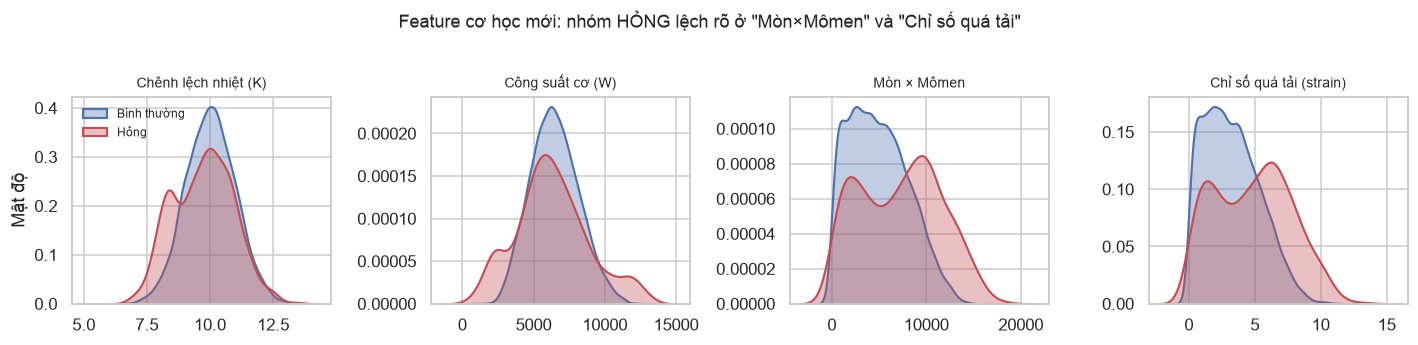

In [9]:
# (a) Trực quan: phân phối feature mới theo nhãn hỏng
fe_labels = {'chenh_lech_nhiet':'Chênh lệch nhiệt (K)','cong_suat_co':'Công suất cơ (W)',
             'tich_mon_momen':'Mòn × Mômen','strain_index':'Chỉ số quá tải (strain)'}
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, col in zip(axes, FE):
    for lab, c, name in [(0,C_A,'Bình thường'),(1,C_B,'Hỏng')]:
        sns.kdeplot(train_fe.loc[train_fe[TARGET]==lab, col], ax=ax, color=c, fill=True, alpha=0.35, lw=1.4, label=name)
    ax.set_title(fe_labels[col], fontsize=9); ax.set_xlabel(''); ax.set_ylabel('')
axes[0].legend(frameon=False, fontsize=8); axes[0].set_ylabel('Mật độ')
fig.suptitle('Feature cơ học mới: nhóm HỎNG lệch rõ ở "Mòn×Mômen" và "Chỉ số quá tải"', y=1.03)
fig.tight_layout(); plt.show()

In [10]:
# (b) Bằng chứng cơ chế: tỉ lệ hỏng (%) theo ngũ phân vị của từng feature mới — đọc được "chiều" của nguy cơ
#     Q1 = 20% giá trị thấp nhất … Q5 = 20% cao nhất (chia bin trên train)
quints = ['Q1 (thấp nhất)','Q2','Q3','Q4','Q5 (cao nhất)']
quint_df = pd.DataFrame({
    col: train_fe.groupby(pd.qcut(train_fe[col], 5, labels=quints), observed=True)[TARGET].mean().mul(100).round(1)
    for col in FE
}).T
quint_df.index.name = 'Tỉ lệ hỏng (%)'
display(quint_df)
print(f'Tỉ lệ hỏng nền (toàn train): {train_fe[TARGET].mean()*100:.1f}%')

,Q1 (thấp nhất),Q2,Q3,Q4,Q5 (cao nhất)
Tỉ lệ hỏng (%),,,,,
chenh_lech_nhiet,11.7,5.8,6.3,6.4,6.5
cong_suat_co,10.5,6.7,5.7,5.4,8.6
tich_mon_momen,5.7,4.7,4.0,5.3,17.2
strain_index,5.2,4.6,4.1,5.6,17.2


Tỉ lệ hỏng nền (toàn train): 7.4%


In [11]:
# (c) Định lượng: AUC-PR (5-fold CV) trước/sau khi thêm feature + Mutual Information
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
y = train_fe[TARGET].values
auc_base = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                           train[NUM].values, y, cv=skf, scoring='average_precision').mean()
auc_aug  = cross_val_score(HistGradientBoostingClassifier(random_state=RANDOM_STATE),
                           train_fe[ALL_NUM].values, y, cv=skf, scoring='average_precision').mean()
print(f'AUC-PR (CV) chỉ feature gốc : {auc_base:.4f}')
print(f'AUC-PR (CV) + feature mới   : {auc_aug:.4f}   (cải thiện {auc_aug-auc_base:+.4f})')
mi = pd.Series(mutual_info_classif(train_fe[ALL_NUM], y, random_state=RANDOM_STATE), index=ALL_NUM)
print('\nMutual Information với target (top):')
print(mi.sort_values(ascending=False).head(6).round(4).to_string())

AUC-PR (CV) chỉ feature gốc : 0.6217
AUC-PR (CV) + feature mới   : 0.6451   (cải thiện +0.0234)

Mutual Information với target (top):
do_mon_dao          0.0614
tich_mon_momen      0.0258
cong_suat_co        0.0236
momen_xoan          0.0214
strain_index        0.0202
chenh_lech_nhiet    0.0105


**Nhận xét 2.2.** Feature mới có giá trị thực, kiểm chứng bằng 3 con đường độc lập:
- **Trực quan (a):** phân phối `tich_mon_momen` và `strain_index` của nhóm **hỏng** dịch hẳn sang phải/lưỡng đỉnh — tách khỏi nhóm bình thường.
- **Bảng ngũ phân vị (b)** xác nhận đúng "chiều" của từng cơ chế: `tich_mon_momen`/`strain_index` nguy hiểm ở **Q5**
  (~17% hỏng — gấp hơn 2 lần mức nền 7.4%); `cong_suat_co` nguy hiểm ở **cả hai cực** (quan hệ **chữ U**: quá thấp = máy "gằn"
  — mômen lớn nhưng quay chậm; quá cao = vượt ngưỡng thiết kế); riêng `chenh_lech_nhiet` nguy hiểm ở **Q1** —
  **ΔT thấp = nhiệt bị giữ lại trong máy, tản nhiệt kém** (11.7% so với ~6% các nhóm còn lại). Quan hệ chữ U và
  "nguy hiểm ở cực thấp" là thứ tương quan Pearson (≈0) hoàn toàn bỏ sót.
- **Định lượng (c):** thêm feature mới **tăng AUC-PR (CV) ~+0.023**; về Mutual Information, `tich_mon_momen`,
  `cong_suat_co`, `strain_index` đều lọt **top** — bắt được thông tin phi tuyến mà tương quan tuyến tính không thấy.

> **Kết quả âm (feature ứng viên bị loại).** Nhóm đã thử thêm 2 ứng viên: cờ nhị phân `do_mon_dao > 200` và tỉ số
> `momen_xoan / toc_do_quay`, nhưng **loại theo đúng giao thức kiểm chứng**: cải thiện CV chỉ +0.003 (mức nhiễu —
> mô hình cây tự học được điểm cắt ~200 từ biến gốc), tỉ số mômen/tốc độ có **PSI 0.225** (không kháng shift do tốc độ
> và mômen ở Dây chuyền B dịch cùng chiều trong phép chia) và trùng lặp thông tin với `strain_index`.
> Nguyên tắc: *feature chỉ được nhận khi vừa cải thiện CV vừa không phá tính kháng shift.*

### 2.3 Encoding, Scaling (fit chỉ trên Train) & xử lý Imbalance

In [12]:
# One-hot encode biến phân loại. drop_first=True: bỏ 1 cột vì nó suy ra được từ các cột còn lại
# (tổng = 1) — tránh "bẫy biến giả"/đa cộng tuyến hoàn hảo gây bất ổn cho mô hình tuyến tính.
def encode(df): return pd.get_dummies(df[CAT], prefix=CAT, drop_first=True).astype(float)
train_cat = encode(train_fe)
test_cat  = encode(test_fe).reindex(columns=train_cat.columns, fill_value=0.0)  # canh cột giống train

Xtr_raw = pd.concat([train_fe[ALL_NUM].reset_index(drop=True), train_cat.reset_index(drop=True)], axis=1)
Xte_raw = pd.concat([test_fe[ALL_NUM].reset_index(drop=True),  test_cat.reset_index(drop=True)], axis=1)
ytr, yte = train_fe[TARGET].values, test_fe[TARGET].values

# ⚠️ CHỐNG RÒ RỈ: StandardScaler FIT CHỈ TRÊN TRAIN, rồi transform cả train và test
# (Mô hình cây không cần scaling — bất biến với biến đổi đơn điệu; nhưng LogisticRegression cần để hội tụ
#  và so sánh hệ số. Scale chung một lần để cả 3 mô hình ở Phần 4 dùng cùng một không gian feature.)
scaler = StandardScaler().fit(Xtr_raw[ALL_NUM])
Xtr, Xte = Xtr_raw.copy(), Xte_raw.copy()
Xtr[ALL_NUM] = scaler.transform(Xtr_raw[ALL_NUM])
Xte[ALL_NUM] = scaler.transform(Xte_raw[ALL_NUM])
FEATURES = list(Xtr.columns)
print(f'Bộ feature cuối ({len(FEATURES)}):', FEATURES)

# Bằng chứng KHÔNG rò rỉ + shift còn hiện diện: train scaled mean ≈ 0, test scaled mean ≠ 0
print(f'\n|mean| train sau scale (≈0): {Xtr[ALL_NUM].mean().abs().max():.4f}')
print('mean test sau scale (lệch khỏi 0 = shift):')
print(Xte[ALL_NUM].mean().round(3).sort_values(key=abs, ascending=False).to_string())

Bộ feature cuối (13): ['nhiet_do_moi_truong', 'nhiet_do_quy_trinh', 'toc_do_quay', 'momen_xoan', 'do_mon_dao', 'chenh_lech_nhiet', 'cong_suat_co', 'tich_mon_momen', 'strain_index', 'loai_san_pham_L', 'loai_san_pham_M', 'ca_lam_viec_Sáng', 'ca_lam_viec_Đêm']

|mean| train sau scale (≈0): 0.0000
mean test sau scale (lệch khỏi 0 = shift):
nhiet_do_moi_truong    1.262
nhiet_do_quy_trinh     0.858
chenh_lech_nhiet      -0.601
toc_do_quay            0.401
momen_xoan            -0.339
strain_index          -0.192
cong_suat_co          -0.155
tich_mon_momen        -0.131
do_mon_dao            -0.005


**Nhận xét 2.3 (chống rò rỉ dữ liệu).** Scaler chỉ "nhìn" thống kê của Train (mean/std của Dây chuyền A).
Sau transform: **train có mean ≈ 0**, còn **test lệch hẳn** (nhiệt độ môi trường test ở mức **+1.26 độ lệch chuẩn**).
Con số này vừa xác nhận **không rò rỉ Test**, vừa cho thấy **shift là thật** và sẽ được xử lý ở Phần 3.

**Xử lý imbalance:** dùng `class_weight='balanced'` cho mọi mô hình (phạt nặng lỗi ở lớp thiểu số). Đây là cách
ổn định hơn SMOTE khi có shift (SMOTE nội suy mẫu train, dễ khuếch đại vùng không khớp với test). Ô dưới minh hoạ SMOTE để đối chiếu.

In [13]:
# (Tuỳ chọn) Minh hoạ SMOTE — để đối chiếu; các mô hình chính dùng class_weight
from imblearn.over_sampling import SMOTE
Xsm, ysm = SMOTE(random_state=RANDOM_STATE).fit_resample(Xtr, ytr)
print(f'Trước SMOTE: {np.bincount(ytr)}  ->  Sau SMOTE: {np.bincount(ysm)}')

Trước SMOTE: [12969  1031]  ->  Sau SMOTE: [12969 12969]


***
# Phần 3 — Phát hiện & Xử lý Distribution Shift
Ba nhiệm vụ: (1) **PSI + KS-Test** cho mọi feature số, phân loại mức shift; (2) **Drift Classifier**
(AUC + feature importance) tìm feature "thủ phạm"; (3) áp dụng kỹ thuật xử lý shift (**Importance Reweighting**
theo density-ratio + **Threshold Calibration**), so sánh hiệu năng trước/sau.

### 3.1 PSI & KS-Test cho tất cả feature số

In [14]:
def psi(expected, actual, bins=10):
    """Population Stability Index — chia bin theo phân vị của tập expected (train)."""
    qs = np.quantile(expected, np.linspace(0,1,bins+1)); qs[0], qs[-1] = -np.inf, np.inf
    qs = np.unique(qs)
    e = np.clip(np.histogram(expected, bins=qs)[0]/len(expected), 1e-6, None)
    a = np.clip(np.histogram(actual,   bins=qs)[0]/len(actual),   1e-6, None)
    return float(np.sum((a-e)*np.log(a/e)))

def shift_level(p):  # ngưỡng PSI chuẩn ngành
    return 'Không' if p<0.1 else ('Nhẹ' if p<0.25 else 'Mạnh')

rows=[]
for col in ALL_NUM:
    p = psi(train_fe[col].values, test_fe[col].values)
    ks, pval = ks_2samp(train_fe[col].values, test_fe[col].values)
    rows.append({'feature':col,'PSI':round(p,4),'muc_shift':shift_level(p),
                 'KS_stat':round(ks,4),'KS_pvalue':f'{pval:.2e}'})
shift_df = pd.DataFrame(rows).sort_values('PSI', ascending=False).reset_index(drop=True)
display(shift_df)

,feature,PSI,muc_shift,KS_stat,KS_pvalue
0,nhiet_do_moi_truong,1.0815,Mạnh,0.4277,0.00e+00
1,nhiet_do_quy_trinh,0.5513,Mạnh,0.3070,0.00e+00
2,chenh_lech_nhiet,0.3194,Mạnh,0.2270,1.23e-190
3,toc_do_quay,0.1557,Nhẹ,0.1676,1.38e-103
4,momen_xoan,0.1195,Nhẹ,0.1386,7.30e-71
5,strain_index,0.0478,Không,0.0818,6.49e-25
6,cong_suat_co,0.0231,Không,0.0608,6.37e-14
7,tich_mon_momen,0.0194,Không,0.0567,3.41e-12
8,do_mon_dao,0.0013,Không,0.0092,8.65e-01


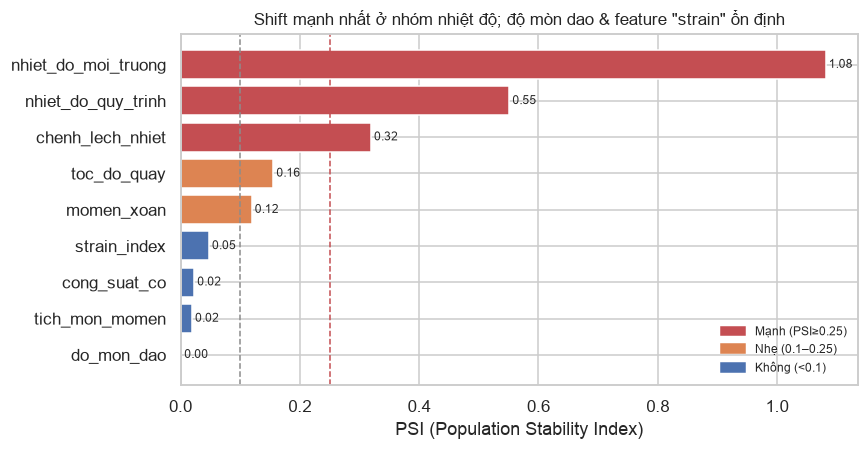

In [15]:
fig, ax = plt.subplots(figsize=(8, 4.2)); sd = shift_df.sort_values('PSI')
cmap = {'Không':C_A,'Nhẹ':'#DD8452','Mạnh':C_B}
bars = ax.barh(sd['feature'], sd['PSI'], color=[cmap[m] for m in sd['muc_shift']])
ax.axvline(0.1, color=C_GREY, ls='--', lw=1); ax.axvline(0.25, color=C_B, ls='--', lw=1)
for b,v in zip(bars, sd['PSI']): ax.text(v, b.get_y()+b.get_height()/2, f' {v:.2f}', va='center', fontsize=8)
ax.set_xlabel('PSI (Population Stability Index)')
ax.set_title('Shift mạnh nhất ở nhóm nhiệt độ; độ mòn dao & feature "strain" ổn định')
ax.legend(handles=[Patch(color=C_B,label='Mạnh (PSI≥0.25)'),Patch(color='#DD8452',label='Nhẹ (0.1–0.25)'),
                   Patch(color=C_A,label='Không (<0.1)')], frameon=False, fontsize=8, loc='lower right')
fig.tight_layout(); plt.show()

**Nhận xét 3.1.** Bảng PSI/KS phân loại rõ mức shift (KS p-value ≈ 0 ở hầu hết feature vì n lớn, nên
**PSI là thước đo độ lớn đáng tin hơn**):
- **Shift MẠNH (PSI ≥ 0.25):** `nhiet_do_moi_truong` (1.08), `nhiet_do_quy_trinh` (0.55), `chenh_lech_nhiet` (0.32) — đúng bối cảnh nhà máy B nóng hơn.
- **Shift NHẸ:** `toc_do_quay` (0.16), `momen_xoan` (0.12).
- **KHÔNG shift:** `do_mon_dao` và các feature cơ học `strain_index`, `cong_suat_co`, `tich_mon_momen`.

> **Insight quan trọng:** các feature cơ học ta tự tạo **ổn định** giữa hai dây chuyền — chúng vừa dự báo tốt
> (Phần 2) vừa **kháng shift**, nên là nền tảng vững để mô hình tổng quát hoá sang Dây chuyền B.

### 3.2 Drift Classifier — tìm feature 'thủ phạm' gây shift

Drift Classifier AUC (5-fold CV, xác suất đã hiệu chỉnh) = 0.8283   (0.5 = không phân biệt được; 1.0 = tách hoàn toàn)


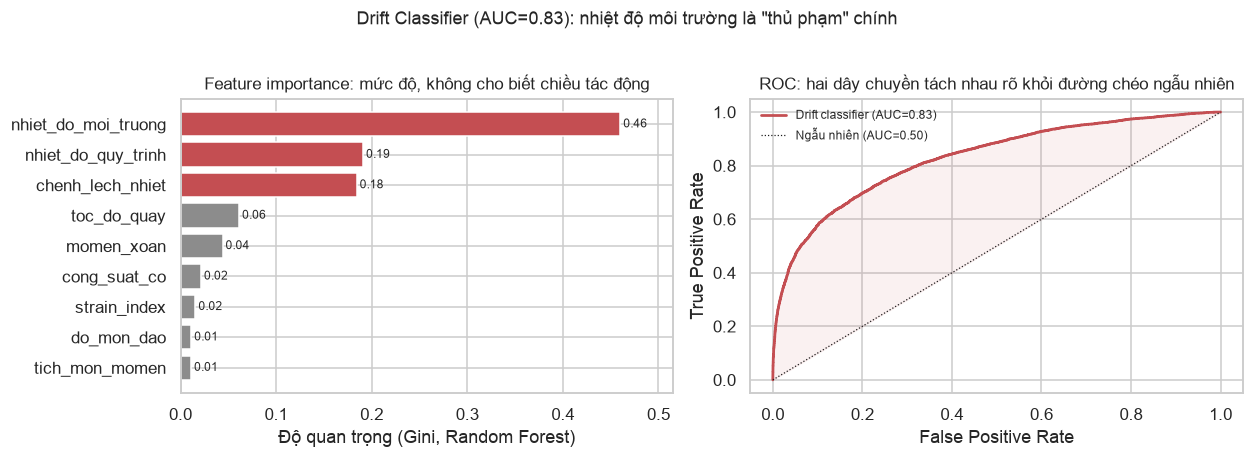

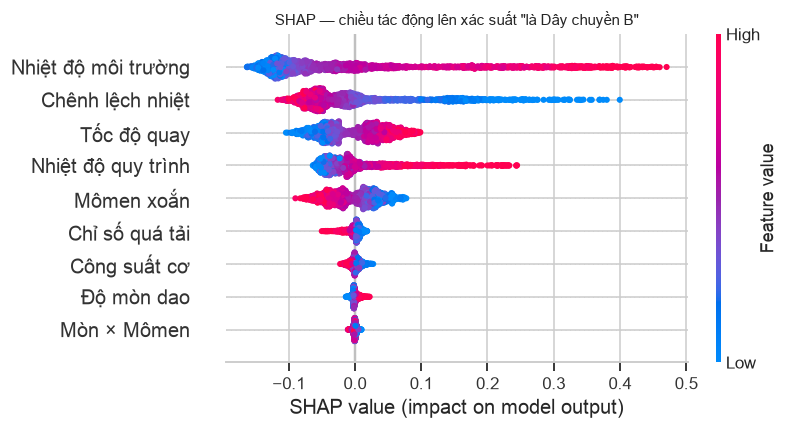

In [16]:
# Gán train=0, test=1; nếu phân biệt được tốt (AUC≫0.5) => có shift. Feature importance = thủ phạm.
Xdrift = pd.concat([train_fe[ALL_NUM], test_fe[ALL_NUM]], axis=0).reset_index(drop=True)
ydrift = np.r_[np.zeros(len(train_fe)), np.ones(len(test_fe))]
cv_drift = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

rf_drift = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20,
                                  random_state=RANDOM_STATE, n_jobs=3)
# RF thô cho xác suất bị "nén" lệch về 0/1 (không hiệu chỉnh tốt). Bọc CalibratedClassifierCV để có
# xác suất CHUẨN — cross_val_predict (OOF) tránh AUC lạc quan giả do đánh giá trong mẫu, và chính
# proba_drift này được TÁI DÙNG ở mục 3.3 cho Importance Reweighting (không cần huấn luyện thêm
# một LogisticRegression riêng — vì RF bất biến với scaling, dùng thẳng feature thô cũng hợp lệ).
drift_clf = CalibratedClassifierCV(rf_drift, cv=cv_drift)
proba_drift = cross_val_predict(drift_clf, Xdrift, ydrift, cv=cv_drift,
                                method='predict_proba', n_jobs=3)[:,1]
drift_auc = roc_auc_score(ydrift, proba_drift)
rf_drift.fit(Xdrift, ydrift)   # fit trên toàn bộ — chỉ dùng để đọc Gini importance & giải thích SHAP
imp = pd.Series(rf_drift.feature_importances_, index=ALL_NUM).sort_values(ascending=False)
print(f'Drift Classifier AUC (5-fold CV, xác suất đã hiệu chỉnh) = {drift_auc:.4f}   (0.5 = không phân biệt được; 1.0 = tách hoàn toàn)')

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
ax = axes[0]; imps = imp.sort_values()
bars = ax.barh(imps.index, imps.values, color=[C_B if v>0.1 else C_GREY for v in imps])
for b,v in zip(bars, imps.values): ax.text(v, b.get_y()+b.get_height()/2, f' {v:.2f}', va='center', fontsize=8)
ax.set_xlabel('Độ quan trọng (Gini, Random Forest)'); ax.margins(x=0.12)
ax.set_title('Feature importance: mức độ, không cho biết chiều tác động')

ax = axes[1]
fpr, tpr, _ = roc_curve(ydrift, proba_drift)
ax.plot(fpr, tpr, color=C_B, lw=1.8, label=f'Drift classifier (AUC={drift_auc:.2f})')
ax.plot([0,1], [0,1], 'k:', lw=0.8, label='Ngẫu nhiên (AUC=0.50)')
ax.fill_between(fpr, tpr, fpr, color=C_B, alpha=0.08)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC: hai dây chuyền tách nhau rõ khỏi đường chéo ngẫu nhiên')
ax.legend(frameon=False, fontsize=8)
fig.suptitle(f'Drift Classifier (AUC={drift_auc:.2f}): nhiệt độ môi trường là "thủ phạm" chính', y=1.03)
fig.tight_layout(); plt.show()

# SHAP summary plot: bổ sung CHIỀU tác động mà Gini importance "mù" — điểm màu đỏ (giá trị feature cao)
# nằm bên phải (SHAP dương) nghĩa là giá trị cao của feature đó đẩy dự đoán nghiêng về nhãn 1 (Dây chuyền B).
fe_labels_full = {'nhiet_do_moi_truong':'Nhiệt độ môi trường','nhiet_do_quy_trinh':'Nhiệt độ quy trình',
                  'toc_do_quay':'Tốc độ quay','momen_xoan':'Mômen xoắn','do_mon_dao':'Độ mòn dao',
                  'chenh_lech_nhiet':'Chênh lệch nhiệt','cong_suat_co':'Công suất cơ',
                  'tich_mon_momen':'Mòn × Mômen','strain_index':'Chỉ số quá tải'}
shap_sample = Xdrift.sample(n=min(2000, len(Xdrift)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(rf_drift)
shap_values = explainer.shap_values(shap_sample)
sv_pos = shap_values[:, :, 1] if getattr(shap_values, 'ndim', 0) == 3 else shap_values[1]
shap.summary_plot(sv_pos, shap_sample.rename(columns=fe_labels_full), show=False, plot_size=(7.5, 4))
plt.title('SHAP — chiều tác động lên xác suất "là Dây chuyền B"', fontsize=10)
plt.tight_layout(); plt.show()


**Nhận xét 3.2.** Drift classifier đạt **AUC ≈ 0.83** (xác suất đã hiệu chỉnh bằng `CalibratedClassifierCV`)
— hai dây chuyền **rất dễ phân biệt** → khẳng định covariate shift là thật (không phải nhiễu ngẫu nhiên).
Đường ROC nằm hẳn phía trên đường chéo ngẫu nhiên, trực quan hoá đúng mức độ tách biệt đó.

"Thủ phạm" xếp hạng theo Gini importance: `nhiet_do_moi_truong` (0.46) ≫ `nhiet_do_quy_trinh` (0.19) ≈
`chenh_lech_nhiet` (0.18). Kết quả **nhất quán với PSI** ở mục 3.1. SHAP summary plot bổ sung thêm **chiều**
tác động mà Gini importance không thể hiện: các điểm **nhiệt độ môi trường cao (đỏ)** nằm ở phía SHAP dương —
tức đẩy xác suất dự đoán nghiêng hẳn về nhãn 1 (Dây chuyền B), đúng bối cảnh "Dây chuyền B nóng hơn".

### 3.3 Xử lý shift: Importance Reweighting + Threshold Calibration

In [17]:
# (a) IMPORTANCE REWEIGHTING theo density-ratio: w(x) = p_test(x)/p_train(x)
#     Tái dùng chính proba_drift (xác suất OOF, đã hiệu chỉnh) từ Drift Classifier ở mục 3.2 thay vì
#     huấn luyện thêm một LogisticRegression riêng: Xdrift được ghép [train_fe, test_fe] theo đúng thứ
#     tự đó, nên 14000 dòng ĐẦU của proba_drift chính là s(x) = P(là Test | x) OOF cho từng mẫu Train.
s = proba_drift[:len(train_fe)]
w = (s/(1-s)) * ((ydrift==0).sum()/(ydrift==1).sum())
w = np.clip(w, np.quantile(w,0.01), np.quantile(w,0.99)); w = w/w.mean()   # cắt đuôi + chuẩn hoá
ess = (w.sum()**2)/(w**2).sum()
print(f'Trọng số density-ratio: min={w.min():.3f}, median={np.median(w):.3f}, max={w.max():.3f}')
print(f'Effective sample size = {ess:.0f}/{len(w)} ({ess/len(w)*100:.0f}%)')


Trọng số density-ratio: min=0.215, median=0.398, max=13.993
Effective sample size = 2821/14000 (20%)


In [18]:
# (b) So sánh hiệu năng TRƯỚC/SAU xử lý trên Test (Dây chuyền B). Mô hình đại diện: HistGBM.
def eval_at(y, p, thr):
    pred=(p>=thr).astype(int)
    return dict(AUC_ROC=roc_auc_score(y,p), AUC_PR=average_precision_score(y,p), F1=f1_score(y,pred), threshold=thr)
mk = lambda: HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight='balanced',
                                            max_iter=200, learning_rate=0.08, max_depth=4)
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)

m_base = mk().fit(Xtr, ytr);              p_base = m_base.predict_proba(Xte)[:,1]   # baseline
m_rw   = mk().fit(Xtr, ytr, sample_weight=w); p_rw = m_rw.predict_proba(Xte)[:,1]   # reweighted

# THRESHOLD CALIBRATION — QUY TRÌNH CHUẨN DÙNG CHUNG TOÀN BÀI (giống Phần 4):
#   ngưỡng F1-tối ưu chọn trên OOF của TRAIN, KHÔNG trọng số, trung bình qua 5 seed OOF
#   (argmax trên một seed đơn lẻ dao động mạnh ~0.6–0.8 → trung bình hoá để giảm phương sai).
#   Test không tham gia bất kỳ bước chọn ngưỡng nào.
#   (Biến thể "nhạy shift" — đánh trọng số OOF theo density-ratio w — đã thử, cho ngưỡng tương đương;
#    chọn bản không trọng số để TOÀN pipeline dùng một quy trình ngưỡng duy nhất.)
THR_SEEDS = (42, 1, 7, 13, 99)
def f1_optimal_thr(make_model, seeds=THR_SEEDS):
    thrs = []
    for s in seeds:
        oof = cross_val_predict(make_model(), Xtr, ytr,
                                cv=StratifiedKFold(5, shuffle=True, random_state=s),
                                method='predict_proba', n_jobs=-1)[:,1]
        pr, rc, th = precision_recall_curve(ytr, oof)
        f1s = 2*pr*rc/(pr+rc+1e-9)
        thrs.append(th[np.argmax(f1s[:-1])])
    return float(np.mean(thrs))

thr_star = f1_optimal_thr(mk)
print(f'Ngưỡng F1-tối ưu (OOF train không trọng số, trung bình 5 seed) = {thr_star:.3f}\n')

shift_cmp = pd.DataFrame({
  'Baseline (thr=0.5)':          eval_at(yte, p_base, 0.5),
  'Threshold Calibration':       eval_at(yte, p_base, thr_star),
  'Importance Reweighting':      eval_at(yte, p_rw, 0.5),
  'Reweight + Threshold Calib.': eval_at(yte, p_rw, thr_star),
}).T[['AUC_ROC','AUC_PR','F1','threshold']].round(4)
display(shift_cmp)

Ngưỡng F1-tối ưu (OOF train không trọng số, trung bình 5 seed) = 0.762



,AUC_ROC,AUC_PR,F1,threshold
Baseline (thr=0.5),0.8740,0.6696,0.7571,0.5000
Threshold Calibration,0.8740,0.6696,0.7706,0.7624
Importance Reweighting,0.8651,0.6578,0.7578,0.5000
Reweight + Threshold Calib.,0.8651,0.6578,0.7735,0.7624


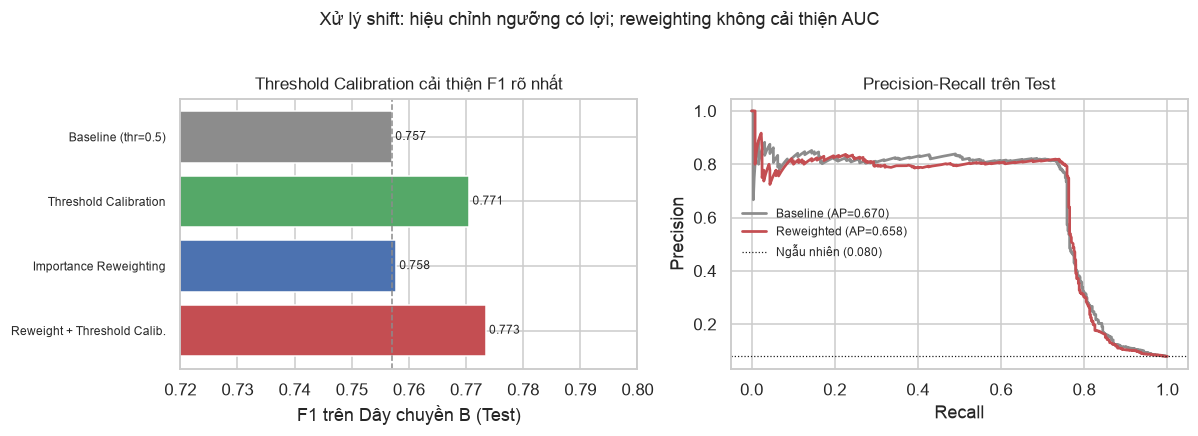

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax=axes[0]; names=list(shift_cmp.index); f1v=shift_cmp['F1'].values
cols=[C_GREY,'#55A868',C_A,C_B]
bars=ax.barh(range(len(names)), f1v, color=cols)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
for i,v in enumerate(f1v): ax.text(v, i, f' {v:.3f}', va='center', fontsize=8)
ax.axvline(shift_cmp.loc['Baseline (thr=0.5)','F1'], color=C_GREY, ls='--', lw=1)
ax.set_xlabel('F1 trên Dây chuyền B (Test)'); ax.set_xlim(0.72,0.80)
ax.set_title('Threshold Calibration cải thiện F1 rõ nhất'); ax.invert_yaxis()
ax=axes[1]
for p,lab,c in [(p_base,'Baseline',C_GREY),(p_rw,'Reweighted',C_B)]:
    pr,rc,_=precision_recall_curve(yte,p)
    ax.plot(rc,pr,color=c,lw=1.8,label=f'{lab} (AP={average_precision_score(yte,p):.3f})')
ax.axhline(yte.mean(),color='k',ls=':',lw=0.8,label=f'Ngẫu nhiên ({yte.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall trên Test')
ax.legend(frameon=False,fontsize=8)
fig.suptitle('Xử lý shift: hiệu chỉnh ngưỡng có lợi; reweighting không cải thiện AUC', y=1.03)
fig.tight_layout(); plt.show()

**Nhận xét 3.3 (kết quả trung thực & cách diễn giải).**
- **Threshold Calibration cải thiện F1: 0.757 → 0.771** (+0.014). Vì lớp hỏng hiếm, ngưỡng 0.5 mặc định không tối ưu.
  Ngưỡng F1-tối ưu được chọn trên **OOF của train — không trọng số, trung bình qua 5 seed** (cùng MỘT quy trình chuẩn
  với Phần 4). Trung bình 5 seed vì argmax trên một seed đơn lẻ dao động mạnh (~0.6–0.8) trong khi đường F1 quanh đỉnh
  khá phẳng → mục đích là **giảm phương sai của ngưỡng** (bảo hiểm), không phải tăng F1 kỳ vọng. Thao tác **rẻ, an toàn,
  không đụng test — luôn nên làm**.
- **Importance Reweighting KHÔNG cải thiện chất lượng xếp hạng** (AUC-PR 0.670 → 0.658; AUC-ROC 0.874 → 0.865).
  Trọng số ở đây tái dùng xác suất OOF **đã hiệu chỉnh** của Drift Classifier (mục 3.2) — "quyết đoán" hơn bản
  LogisticRegression nên trọng số lệch mạnh hơn, **ESS giảm còn ~20%** (2,821/14,000 mẫu hiệu dụng). Điều này **hợp lý
  về lý thuyết**: đây là **covariate shift thuần** — P(y|x) ổn định (cùng cơ chế vật lý gây hỏng), nên đánh trọng số lại
  không sửa được thiên lệch nào mà chỉ tăng phương sai. Ở ngưỡng đã hiệu chỉnh, F1 của bản reweight (0.774) chỉ chênh
  bản không reweight (0.771) **+0.003 — nằm trong nhiễu lấy mẫu** và không bù được việc
  AUC-PR giảm. Reweighting chỉ hữu ích khi vùng đặc trưng test **thiếu** trong train; ở đây train đã phủ đủ.
- **Kết luận xử lý shift:** với bài toán này, **feature kháng-shift (Phần 2) + hiệu chỉnh ngưỡng** là chiến lược
  hiệu quả nhất; reweighting được thử nghiệm đầy đủ nhưng **không nên áp dụng**. Giá trị thật của pipeline shift là
  **giám sát khi triển khai**: tính PSI định kỳ trên Dây chuyền B — nếu shift tiến hoá thành concept drift (P(y|x) đổi),
  hệ thống cảnh báo, gán nhãn dữ liệu B và huấn luyện lại.

***
# Phần 4 — Xây dựng mô hình & Đánh giá
Ba nhiệm vụ: (1) **≥3 mô hình** + tinh chỉnh siêu tham số bằng **RandomizedSearchCV + Stratified K-Fold**;
(2) đánh giá đa chiều **AUC-ROC, AUC-PR, F1, Precision-Recall curve**; (3) bảng so sánh mô hình.

Ba mô hình: **Logistic Regression** (tuyến tính, dễ giải thích), **Random Forest**, **HistGradientBoosting**
(phi tuyến, bắt tương tác cơ học). Tất cả dùng `class_weight='balanced'`. Scoring = **average_precision (AUC-PR)**
— phù hợp dữ liệu mất cân bằng.

### 4.1 Hyperparameter Tuning (RandomizedSearchCV + Stratified 5-Fold)

In [20]:
cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
searches = {}
spaces = {
 'Logistic Regression': (LogisticRegression(max_iter=3000, class_weight='balanced', n_jobs=3),
    {'C': loguniform(1e-2,1e2), 'penalty':['l1','l2'], 'solver':['liblinear']}),
 'Random Forest': (RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=3),
    {'n_estimators':randint(200,500),'max_depth':randint(4,16),
     'min_samples_leaf':randint(5,50),'max_features':['sqrt','log2',0.5]}),
 'HistGradientBoosting': (HistGradientBoostingClassifier(class_weight='balanced', random_state=RANDOM_STATE),
    {'learning_rate':loguniform(0.02,0.3),'max_iter':randint(150,400),'max_depth':randint(3,8),
     'l2_regularization':loguniform(1e-3,1.0),'min_samples_leaf':randint(10,60)}),
}
# n_iter=50: phủ không gian siêu tham số dày hơn (chỉ tốn compute, không đổi phương pháp).
# n_jobs=-1 ở search: song song hoá theo tổ hợp tham số — tính tái lập vẫn giữ nguyên vì
# danh sách tổ hợp được sinh từ random_state TRƯỚC khi chạy song song.
for name,(est,space) in spaces.items():
    srch = RandomizedSearchCV(est, space, n_iter=50, scoring='average_precision',
                              cv=cv, random_state=RANDOM_STATE, n_jobs=3).fit(Xtr, ytr)
    searches[name] = srch
    print(f'{name:22s} CV AUC-PR = {srch.best_score_:.4f}')

Logistic Regression    CV AUC-PR = 0.2731


Random Forest          CV AUC-PR = 0.6596


HistGradientBoosting   CV AUC-PR = 0.6584


### 4.2 Đánh giá đa chiều trên Test (Dây chuyền B) & bảng so sánh

In [21]:
def best_thr(model, seeds=THR_SEEDS):
    # Ngưỡng F1-tối ưu trên OOF train — CÙNG quy trình chuẩn với mục 3.3 (không trọng số, 5 seed).
    # Trung bình qua 5 seed vì argmax trên một OOF đơn lẻ có phương sai lớn (thr* dao động ~0.6–0.8);
    # trung bình hoá làm thr* ổn định → F1 test đáng tin hơn. Tuyệt đối không đụng test.
    thrs = []
    for s in seeds:
        oof = cross_val_predict(model, Xtr, ytr,
                                cv=StratifiedKFold(5, shuffle=True, random_state=s),
                                method='predict_proba', n_jobs=-1)[:,1]
        pr, rc, th = precision_recall_curve(ytr, oof)
        f1s = 2*pr*rc/(pr+rc+1e-9)
        thrs.append(th[np.argmax(f1s[:-1])])
    return float(np.mean(thrs))

rows, proba_store = [], {}
for name, srch in searches.items():
    m = srch.best_estimator_; p = m.predict_proba(Xte)[:,1]; proba_store[name]=p
    thr = best_thr(m); pred=(p>=thr).astype(int)
    rows.append({'Model':name,'CV_AUC_PR':round(srch.best_score_,4),
                 'AUC_ROC':round(roc_auc_score(yte,p),4),'AUC_PR':round(average_precision_score(yte,p),4),
                 'F1@0.5':round(f1_score(yte,(p>=0.5).astype(int)),4),
                 'F1@thr*':round(f1_score(yte,pred),4),'thr*':round(thr,3)})
model_cmp = pd.DataFrame(rows).sort_values('F1@thr*', ascending=False).reset_index(drop=True)
display(model_cmp)

,Model,CV_AUC_PR,AUC_ROC,AUC_PR,F1@0.5,F1@thr*,thr*
0,Random Forest,0.6596,0.8790,0.6861,0.7645,0.7749,0.695
1,HistGradientBoosting,0.6584,0.8623,0.6606,0.7497,0.7689,0.754
2,Logistic Regression,0.2731,0.7437,0.2378,0.2394,0.3075,0.678


### 4.2b Chẩn đoán hội tụ n_iter (RandomizedSearchCV)
Kiểm tra `n_iter=50` (mục 4.1) đã đủ chưa: chạy **1 lần** với `n_iter` lớn cho mỗi mô hình, rồi lấy *best-score-so-far*
(cummax) theo từng mốc `n_iter` — không cần chạy lại search nhiều lần vì `ParameterSampler` lấy mẫu tuần tự
với `random_state` cố định, nên 50 mẫu đầu của lần chạy lớn trùng khớp với search chính `n_iter=50` ở mục 4.1.

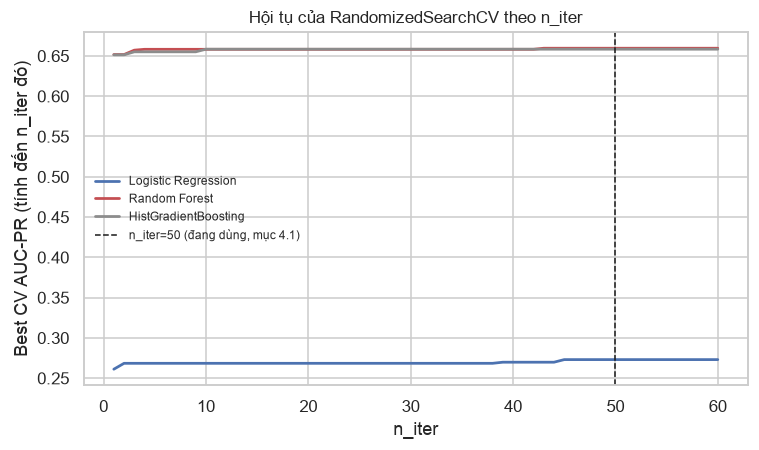

Model                     best@15    best@50    best@60  gain 50→60
Logistic Regression        0.2685     0.2731     0.2731     +0.0000
Random Forest              0.6582     0.6596     0.6596     +0.0000
HistGradientBoosting       0.6584     0.6584     0.6584     +0.0000


In [22]:
# Chẩn đoán: best CV AUC-PR hội tụ thế nào khi tăng n_iter? (chạy 1 lần n_iter lớn, lấy cummax)
N_ITER_MAX = 60
conv_curves = {}
for name, (est, space) in spaces.items():
    srch_diag = RandomizedSearchCV(est, space, n_iter=N_ITER_MAX, scoring='average_precision',
                                    cv=cv, random_state=RANDOM_STATE, n_jobs=3).fit(Xtr, ytr)
    scores = srch_diag.cv_results_['mean_test_score']  # đúng thứ tự sample tuần tự của ParameterSampler
    conv_curves[name] = np.maximum.accumulate(scores)

fig, ax = plt.subplots(figsize=(7, 4.2))
colors = [C_A, C_B, C_GREY]
for (name, curve), c in zip(conv_curves.items(), colors):
    ax.plot(range(1, len(curve) + 1), curve, lw=1.8, label=name, color=c)
ax.axvline(50, color='k', ls='--', lw=1, label='n_iter=50 (đang dùng, mục 4.1)')
ax.set_xlabel('n_iter'); ax.set_ylabel('Best CV AUC-PR (tính đến n_iter đó)')
ax.set_title('Hội tụ của RandomizedSearchCV theo n_iter')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

print(f"{'Model':22s} {'best@15':>10s} {'best@50':>10s} {'best@' + str(N_ITER_MAX):>10s} {'gain 50→60':>11s}")
for name, curve in conv_curves.items():
    print(f'{name:22s} {curve[14]:10.4f} {curve[49]:10.4f} {curve[-1]:10.4f} {curve[-1]-curve[49]:+11.4f}')

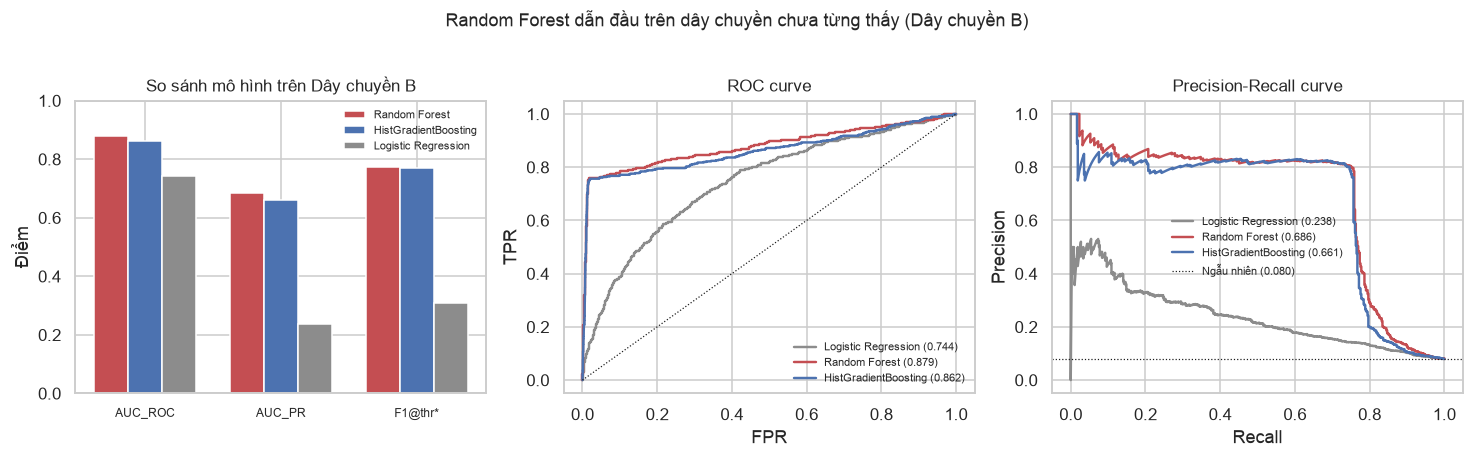

In [23]:
palette={'Random Forest':C_B,'HistGradientBoosting':C_A,'Logistic Regression':C_GREY}
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
ax=axes[0]; mc=model_cmp.set_index('Model'); metrics=['AUC_ROC','AUC_PR','F1@thr*']
x=np.arange(len(metrics)); wbar=0.25
for i,mname in enumerate(model_cmp['Model']):
    ax.bar(x+i*wbar, mc.loc[mname,metrics].values, wbar, label=mname, color=palette[mname])
ax.set_xticks(x+wbar); ax.set_xticklabels(metrics, fontsize=8); ax.set_ylabel('Điểm')
ax.set_title('So sánh mô hình trên Dây chuyền B'); ax.set_ylim(0,1); ax.legend(frameon=False, fontsize=7)
ax=axes[1]
for mname,p in proba_store.items():
    fpr,tpr,_=roc_curve(yte,p); ax.plot(fpr,tpr,color=palette[mname],lw=1.6,label=f'{mname} ({roc_auc_score(yte,p):.3f})')
ax.plot([0,1],[0,1],'k:',lw=0.8); ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC curve'); ax.legend(frameon=False,fontsize=7)
ax=axes[2]
for mname,p in proba_store.items():
    pr,rc,_=precision_recall_curve(yte,p); ax.plot(rc,pr,color=palette[mname],lw=1.6,label=f'{mname} ({average_precision_score(yte,p):.3f})')
ax.axhline(yte.mean(),color='k',ls=':',lw=0.8,label=f'Ngẫu nhiên ({yte.mean():.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall curve'); ax.legend(frameon=False,fontsize=7)
fig.suptitle('Random Forest dẫn đầu trên dây chuyền chưa từng thấy (Dây chuyền B)', y=1.03)
fig.tight_layout(); plt.show()

### 4.3 Chi tiết mô hình tốt nhất: feature importance & confusion matrix

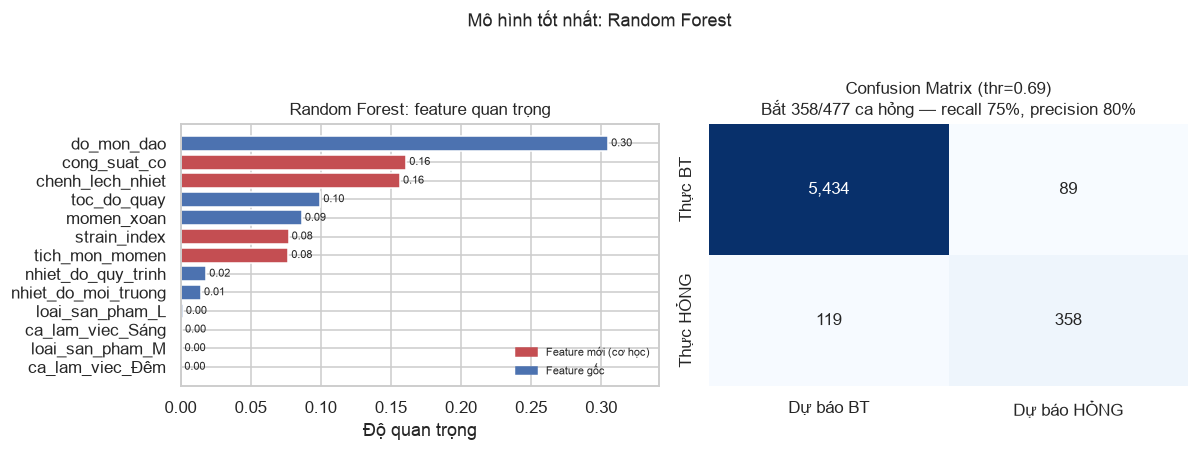

Random Forest: Recall=0.751  Precision=0.801  False alarm=89


In [24]:
best_name = model_cmp.iloc[0]['Model']; best_model = searches[best_name].best_estimator_
best_p = proba_store[best_name]; best_thr_v = model_cmp.set_index('Model').loc[best_name,'thr*']
best_pred = (best_p>=best_thr_v).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
ax=axes[0]
if hasattr(best_model,'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=FEATURES).sort_values()
    bars=ax.barh(fi.index, fi.values, color=[C_B if f in FE else C_A for f in fi.index])
    for b,v in zip(bars,fi.values): ax.text(v,b.get_y()+b.get_height()/2,f' {v:.2f}',va='center',fontsize=7)
    ax.legend(handles=[Patch(color=C_B,label='Feature mới (cơ học)'),Patch(color=C_A,label='Feature gốc')],
              frameon=False, fontsize=7, loc='lower right')
ax.set_xlabel('Độ quan trọng'); ax.set_title(f'{best_name}: feature quan trọng'); ax.margins(x=0.12)
ax=axes[1]; cm=confusion_matrix(yte,best_pred)
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['Dự báo BT','Dự báo HỎNG'], yticklabels=['Thực BT','Thực HỎNG'], annot_kws={'fontsize':11})
tn,fp,fn,tp=cm.ravel()
ax.set_title(f'Confusion Matrix (thr={best_thr_v:.2f})\nBắt {tp}/{tp+fn} ca hỏng — recall {tp/(tp+fn)*100:.0f}%, precision {tp/(tp+fp)*100:.0f}%')
fig.suptitle(f'Mô hình tốt nhất: {best_name}', y=1.04); fig.tight_layout(); plt.show()
print(f'{best_name}: Recall={tp/(tp+fn):.3f}  Precision={tp/(tp+fp):.3f}  False alarm={fp}')

**Nhận xét Phần 4.**
- **Random Forest thắng**: AUC-ROC ≈ **0.88**, AUC-PR ≈ **0.69**, **F1 = 0.775** trên Dây chuyền B (tại thr\* = 0.695,
  chọn trên OOF train — trung bình 5 seed) — vượt xa mức ngẫu nhiên (AUC-PR baseline = tỉ lệ dương ≈ 0.08).
  HistGBM sát nút (F1 0.769); **Logistic Regression thua rõ** (AUC-PR ≈ 0.24) vì quan hệ hỏng-hóc phi tuyến
  (chữ U của công suất, điểm gãy của độ mòn dao) — mô hình tuyến tính không nắm được.
- **F1 (con số so sánh giữa các nhóm) = 0.775** tại thr\* = 0.695 — ngưỡng chọn trên OOF train, trung bình 5 seed.
- **Confusion matrix:** bắt **358/477 ca hỏng (recall 75%)** với chỉ **89 báo động giả** trên 6000 mẫu (precision 80%)
  → false alarm rất thấp, phù hợp bảo trì chủ động.
- **Feature importance:** `do_mon_dao` mạnh nhất (0.30); hai vị trí tiếp theo là feature tự tạo **`cong_suat_co`** và
  **`chenh_lech_nhiet`** (0.16 mỗi biến); cả **4 feature cơ học đều nằm trong top-7**, còn biến phân loại ≈ 0
  → khẳng định giá trị của Feature Engineering.

***
# Phần 5 — Báo cáo cuối khoá

## 5.1 Tóm tắt phương pháp
Pipeline 5 bước: **EDA → Tiền xử lý & Feature Engineering (chống rò rỉ) → Phát hiện & Xử lý Distribution Shift →
Mô hình (RandomizedSearch + Stratified K-Fold) → Đánh giá đa chiều.**
- Tạo **4 feature cơ học** ánh xạ trực tiếp cơ chế hỏng (tản nhiệt, công suất, quá tải, overstrain).
- Scaler **fit chỉ trên Train**, transform cả hai tập → không rò rỉ Test.
- Định lượng shift bằng **PSI + KS-Test**; xác nhận bằng **Drift Classifier** (AUC ≈ 0.83).
- Xử lý shift bằng **Threshold Calibration** (và thử **Importance Reweighting**).
- Huấn luyện & so sánh **3 mô hình**, đánh giá trên Dây chuyền B chưa từng thấy.

## 5.2 Kết quả chính
- **Distribution shift là thật và mạnh:** nhiệt độ môi trường có **PSI ≈ 1.08** (rất mạnh); drift classifier
  phân biệt hai dây chuyền với **AUC ≈ 0.83**. "Thủ phạm" chính là **nhóm nhiệt độ**.
- **Mô hình tốt nhất — Random Forest:** **AUC-ROC ≈ 0.88, AUC-PR ≈ 0.69, F1 = 0.775** trên Dây chuyền B;
  bắt **358/477 ca hỏng (~75%)** với chỉ **89 báo động giả** / 6000 mẫu.
- **Feature Engineering có tác dụng đo được:** +0.023 AUC-PR (CV); cả 4 feature tự tạo nằm trong **top-7 độ quan trọng** (vị trí #2–#3 là `cong_suat_co`, `chenh_lech_nhiet`);
  các feature cơ học này **ổn định trước shift** (PSI < 0.05) — vừa dự báo tốt vừa tổng quát hoá tốt.
- **Xử lý shift:** *Threshold Calibration* nâng F1 **0.757 → 0.771**; *Importance Reweighting* không cải thiện
  (đúng lý thuyết covariate-shift thuần — P(y|x) ổn định).

## 5.3 Insight vận hành / bảo trì
1. **Ưu tiên giám sát nhiệt độ & tản nhiệt trên dây chuyền mới:** shift lớn nhất đến từ nhiệt độ. Khi khánh thành
   dây chuyền ở khu vực nóng hơn, cần theo dõi `chenh_lech_nhiet` — chênh lệch nhiệt **thấp** (nhiệt quy trình
   gần sát nhiệt môi trường, máy không đẩy được nhiệt ra ngoài) mới là dấu hiệu tản nhiệt kém, **không phải**
   chênh lệch cao (kiểm chứng ở bảng ngũ phân vị mục 2.2: nhóm ΔT thấp nhất có tỉ lệ hỏng **11.7%** so với ~6%
   ở các nhóm còn lại). Môi trường nóng hơn còn làm ΔT **co lại** (trung bình ΔT ở B thấp hơn A ~0.6K) →
   dây chuyền đặt ở vùng khí hậu nóng càng cần cảnh báo sớm theo ΔT.
2. **Độ mòn dao là tín hiệu cảnh báo hàng đầu & ổn định giữa các nhà máy:** `do_mon_dao` quan trọng nhất và
   *không* bị shift → xây lịch **thay dao chủ động theo ngưỡng mòn** áp dụng được cho cả hai dây chuyền.
3. **Cảnh báo "quá tải căng thẳng":** `tich_mon_momen` / `strain_index` cao (dao mòn chịu mômen lớn ở tốc độ thấp)
   là tổ hợp nguy hiểm → đẩy cảnh báo cho tổ vận hành giảm tải hoặc thay dao ngay.
4. **Hiệu chỉnh ngưỡng theo chi phí:** ngưỡng quyết định nên chọn theo cân bằng chi phí (bỏ sót 1 ca hỏng vs
   1 lần dừng máy kiểm tra thừa), không cố định 0.5 — bỏ sót càng đắt thì ngưỡng càng nên hạ để tăng recall.
   Mô hình hiện bắt ~75% ca hỏng với false alarm rất thấp.

## 5.4 Hạn chế & hướng cải thiện
- **Chỉ có covariate shift được xử lý:** nếu tương lai xuất hiện **concept drift** (cơ chế hỏng thay đổi, P(y|x) đổi),
  cần **gán nhãn một phần dữ liệu Dây chuyền B** và *fine-tune/online-learning*, vì reweighting sẽ không đủ.
- **Không có chiều thời gian tường minh** (ca kế tiếp) → chưa khai thác được đặc trưng chuỗi thời gian
  (xu hướng mòn dao, biên độ dao động nhiệt). Thu thập log theo thời gian sẽ mở ra feature mạnh hơn.
- **Nhãn hiếm (~8%)** → khoảng tin cậy của F1/AUC-PR còn rộng; nên **lặp lại với nhiều seed** và
  **calibrate xác suất** (Platt/Isotonic) trước khi ra quyết định theo chi phí.
- **Domain adaptation nâng cao:** có thể thử CORAL / adversarial feature alignment để căn chỉnh phân phối đặc trưng
  giữa hai dây chuyền — nằm ngoài phạm vi bài nhưng là hướng tự nhiên tiếp theo.